# 📈 Multiple Linear Regression

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Multiple Linear Regression.
- Differentiate Simple and Multiple Linear Regression.
- Learn the mathematical equation.
- Interpret regression coefficients.
- Build a Multiple Linear Regression model using Scikit-learn.
- Evaluate the model using regression metrics.
- Interpret the model output.

## 📖 Introduction

Multiple Linear Regression is an extension of Simple Linear Regression.

Instead of using only one independent variable, it uses two or more independent variables to predict a continuous target variable.

It helps us understand how multiple factors together influence the target.

## ❓ What is Multiple Linear Regression?

Multiple Linear Regression predicts a continuous value using multiple independent variables.

Example:

Advertising Budget

- TV
- Radio
- Newspaper

↓

Sales

Instead of learning from one feature, the model learns from several features simultaneously.

## 🌍 Real-Life Intuition

A company spends money on:

- TV advertisements
- Radio advertisements
- Newspaper advertisements

The company wants to predict future sales based on these advertising budgets.

Multiple Linear Regression learns the contribution of each advertising channel.

## 📊 Difference

| Simple Linear Regression | Multiple Linear Regression |
|--------------------------|----------------------------|
| One independent variable | Two or more independent variables |
| One coefficient | Multiple coefficients |
| Straight-line relationship | Multi-feature linear relationship |
| Simpler model | More flexible model |

## ➗ Mathematical Equation

The equation is:

ŷ = b₀ + b₁X₁ + b₂X₂ + b₃X₃ + ... + bₙXₙ

Where:

- ŷ = Predicted value
- b₀ = Intercept
- b₁...bₙ = Coefficients
- X₁...Xₙ = Independent variables

## 💡 Interpretation

Each coefficient tells us how much the target variable changes when one feature increases by one unit while keeping all other features constant.

## ✅ Assumptions

- Linear relationship
- Independent observations
- Homoscedasticity
- Normally distributed residuals
- No multicollinearity
- No significant outliers

## ✅ Advantages

- Uses multiple features
- Better predictions
- Easy to interpret
- Fast training
- Strong baseline model

## ❌ Disadvantages

- Sensitive to multicollinearity
- Sensitive to outliers
- Assumes linearity
- Cannot capture complex nonlinear relationships

## 🌍 Applications

- Sales Prediction
- House Price Prediction
- Marketing Analytics
- Demand Forecasting
- Business Analytics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(r"D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\Advertising.csv")

In [3]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [6]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [9]:
X = df[["TV", "radio", "newspaper"]]

y = df["sales"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

Intercept: 2.979067338122629


,Feature,Coefficient
0,TV,0.044730
1,radio,0.189195
2,newspaper,0.002761


In [14]:
y_pred = model.predict(X_test)

In [15]:
comparison = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred
})

comparison.head()

,Actual Sales,Predicted Sales
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


In [16]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE: 1.78159966153345
R² Score: 0.899438024100912


In [17]:
coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,radio,0.189195
0,TV,0.044730
2,newspaper,0.002761


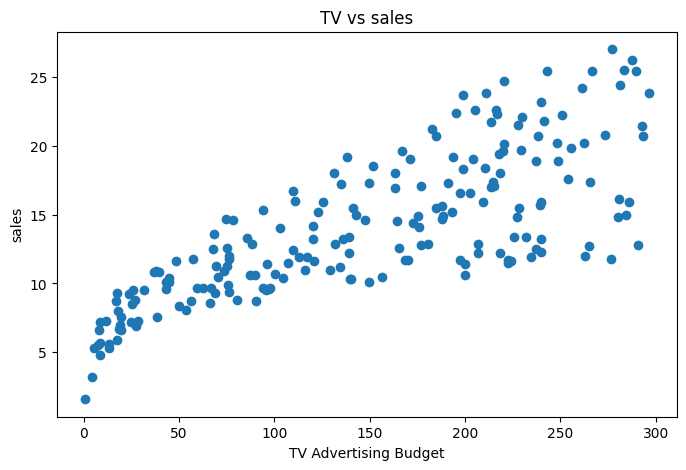

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(df["TV"], df["sales"])

plt.xlabel("TV Advertising Budget")

plt.ylabel("sales")

plt.title("TV vs sales")

plt.show()

## ⚠️ Common Mistakes

- Ignoring multicollinearity
- Including irrelevant features
- Not checking assumptions
- Interpreting coefficients incorrectly

## ✅ Best Practices

- Check feature correlation.
- Remove highly correlated features.
- Evaluate with multiple metrics.
- Interpret coefficients carefully.
- Standardize features if required for comparison.

## 📝 Summary

In this notebook, we extended Simple Linear Regression to Multiple Linear Regression by using multiple input features. We learned how each feature contributes to the prediction, trained a model on the Advertising dataset, evaluated its performance, and interpreted the coefficients.